## Examen Restaurantes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Ingeniería de Datos

In [2]:
users = pd.read_csv('users.csv')
usercuisine = pd.read_csv('usercuisine.csv')
ratings = pd.read_csv('ratings.csv')
restaurants = pd.read_csv('restaurants.csv')
users.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


In [3]:
users.budget = users.budget.map({'low': 1, 'medium': 2, 'high': 3, '?': 0})
users['age'] = 2025 - users['birth_year']

In [4]:
usercuisine.groupby('userID').count()

,Rcuisine
userID,
U1001,1
U1002,1
U1003,1
U1004,9
U1005,1
...,...
U1134,1
U1135,103
U1136,1


In [5]:
users_cuisine = users.join(usercuisine.set_index('userID'), on='userID')
users_cuisine[:10]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,interest,personality,religion,activity,color,weight,budget,height,age,Rcuisine
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,variety,thrifty-protector,none,student,black,69,2,1.77,36,American
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,...,technology,hunter-ostentatious,Catholic,student,red,40,1,1.87,35,Mexican
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,...,none,hard-worker,Catholic,student,blue,60,1,1.69,36,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Bakery
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Breakfast-Brunch
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Japanese
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Contemporary
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Bagels
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,2,1.53,85,Cafe-Coffee_Shop


In [6]:
users_ratings = users.join(ratings.set_index('userID'), on='userID')
users_ratings[:5]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,activity,color,weight,budget,height,age,placeID,rating,food_rating,service_rating
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,2,1.77,36,132830,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,2,1.77,36,132825,2,2,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,2,1.77,36,135085,0,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,2,1.77,36,135040,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,2,1.77,36,135039,1,1,1


In [7]:
users_ratings['frequency'] =users_ratings.groupby(['userID','placeID'])['rating'].transform('count')
    
users_ratings.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,color,weight,budget,height,age,placeID,rating,food_rating,service_rating,frequency
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,2,1.77,36,132830,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,2,1.77,36,132825,2,2,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,2,1.77,36,135085,0,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,2,1.77,36,135040,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,2,1.77,36,135039,1,1,1,1


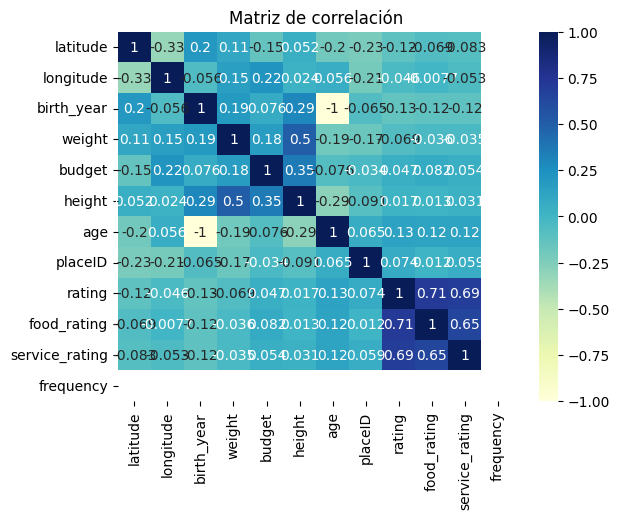

In [8]:
# Matriz de correlación
corr = users_ratings.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

In [9]:
rest_rating =restaurants.join(ratings.set_index('placeID'), on='placeID')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,price,url,Rambience,franchise,area,other_services,userID,rating,food_rating,service_rating
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,medium,kikucuernavaca.com.mx,familiar,f,closed,none,U1093,2,2,2
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,medium,kikucuernavaca.com.mx,familiar,f,closed,none,U1066,1,1,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,medium,kikucuernavaca.com.mx,familiar,f,closed,none,U1040,1,1,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,medium,kikucuernavaca.com.mx,familiar,f,closed,none,U1110,2,2,2
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,medium,kikucuernavaca.com.mx,familiar,f,closed,none,U1121,2,2,2


In [10]:
rest_rating.price = rest_rating.price.map({'low': 1, 'medium': 2, 'high': 3})
rest_rating.franchise = rest_rating.franchise.map({'t': 0, 'f': 1})

In [11]:
rest_rating.groupby('name')['rating'].mean().sort_values(ascending=False).head(20)

name
Restaurant Las Mananitas                   2.000000
Michiko Restaurant Japones                 2.000000
emilianos                                  2.000000
cafe punta del cielo                       1.833333
La Estrella de Dimas                       1.800000
Restaurante la Parroquia Potosina          1.750000
Log Yin                                    1.750000
Giovannis                                  1.750000
la Cochinita Pibil Restaurante Yucateco    1.714286
Mariscos El Pescador                       1.692308
Rincon del Bife                            1.666667
Restaurant Bar Hacienda los Martinez       1.666667
El Rincon de San Francisco                 1.666667
tacos los volcanes                         1.666667
Mariscos Tia Licha                         1.600000
Kiku Cuernavaca                            1.600000
Preambulo Wifi Zone Cafe                   1.583333
Sanborns Casa Piedra                       1.555556
La Virreina                                1.533333
rockabi

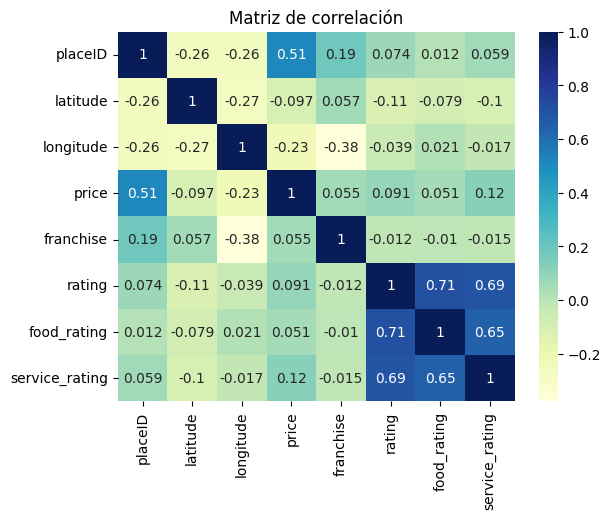

In [12]:
# Matriz de correlación
corr = rest_rating.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()